In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

# plt.rcParams.update({
#     "font.size": 16,          # base font size
#     "axes.labelsize": 18,     # x and y labels
#     "axes.titlesize": 18,     # title
#     "legend.fontsize": 14,    # legend
#     "xtick.labelsize": 14,    # x tick labels
#     "ytick.labelsize": 14,    # y tick labels
# })


sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config

In [2]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.scaled import ConcentrationScaled
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.power_spectra.Pm_computer import Pm_computer

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/plots_Pm_contributions")) 


In [3]:
cfg = Config()
cfg.Q = 4/3
mass_func = MassFuncSheth1999()
c_smooth = ConcentrationNeto2007(cfg)
smooth_profile = ProfileNFW(c_smooth, R_virSO(cfg))

bias = BiasTinker2010(cfg)

c_clump = ConcentrationScaled(cfg, c_smooth)
clump_profile = ProfileNFW(c_clump, 
                           R_virSO(cfg))

cfg_distribution = copy.deepcopy(cfg)
cfg_distribution.Q = 1
c_distribution = ConcentrationScaled(cfg_distribution, c_smooth)
clump_distribution = ProfileNFW(c_distribution, R_virSO(cfg))

clump_mass_func = ClumpMassGiocoli2010(cfg)

In [4]:

Pm_std = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_comps = Pm_computer(Pm_std, k_vals)

interpolating Ic and Jc functions...


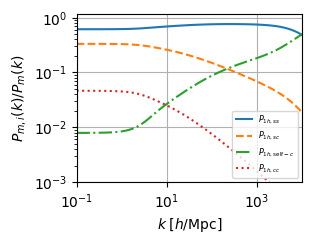

In [5]:

ss_ratio = Pm_comps['P_1h_ss']/Pm_comps['P_1h']
sc_ratio = Pm_comps['P_1h_sc']/Pm_comps['P_1h']
self_c_ratio = Pm_comps['P_1h_self_c']/Pm_comps['P_1h']
cc_ratio = Pm_comps['P_1h_cc']/Pm_comps['P_1h']

# plt.rcParams.update({
#     "font.size": 12,          # base font size
#     "axes.labelsize": 12,     # x and y labels
#     "axes.titlesize": 12,     # title
#     "legend.fontsize": 12,    # legend
#     "xtick.labelsize": 12,    # x tick labels
#     "ytick.labelsize": 12,    # y tick labels
# })

plt.subplot(2,2,1)

plt.plot(k_vals, ss_ratio, label = r'$P_{1h,ss}$', linestyle='-')
plt.plot(k_vals, sc_ratio, label = r'$P_{1h,sc}$', linestyle='--')
plt.plot(k_vals, self_c_ratio, label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
plt.plot(k_vals, cc_ratio, label = r'$P_{1h,cc}$', linestyle=':')

plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-3, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel(r'$k \; [h/\mathrm{Mpc}]$')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend(fontsize='xx-small')

plt.savefig("Pm_1h_ratios.pdf", bbox_inches="tight")
plt.show()


In [11]:
# interpolate giocoli data
from scipy.interpolate import interp1d

# -------------------------
# SS data
# -------------------------
x_ss, y_ss = np.loadtxt(
    "giocoli_data/P_1h_ss.csv",
    delimiter=",",
    unpack=True
)

idx = np.argsort(x_ss)
x_ss = x_ss[idx]
y_ss = y_ss[idx]

f_ss = interp1d(
    np.log(x_ss), y_ss,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

# -------------------------
# SC data
# -------------------------
x_sc, y_sc = np.loadtxt(
    "giocoli_data/P_1h_sc.csv",
    delimiter=",",
    unpack=True
)

idx = np.argsort(x_sc)
x_sc = x_sc[idx]
y_sc = y_sc[idx]

f_sc = interp1d(
    np.log(x_sc), y_sc,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

# -------------------------
# Self-correlation (c)
# -------------------------
x_self_c, y_self_c = np.loadtxt(
    "giocoli_data/P_1h_self_c.csv",
    delimiter=",",
    unpack=True
)

idx = np.argsort(x_self_c)
x_self_c = x_self_c[idx]
y_self_c = y_self_c[idx]

f_self_c = interp1d(
    np.log(x_self_c), y_self_c,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

# -------------------------
# CC data
# -------------------------
x_cc, y_cc = np.loadtxt(
    "giocoli_data/P_1h_cc.csv",
    delimiter=",",
    unpack=True
)

idx = np.argsort(x_cc)
x_cc = x_cc[idx]
y_cc = y_cc[idx]

f_cc = interp1d(
    np.log(x_cc), y_cc,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

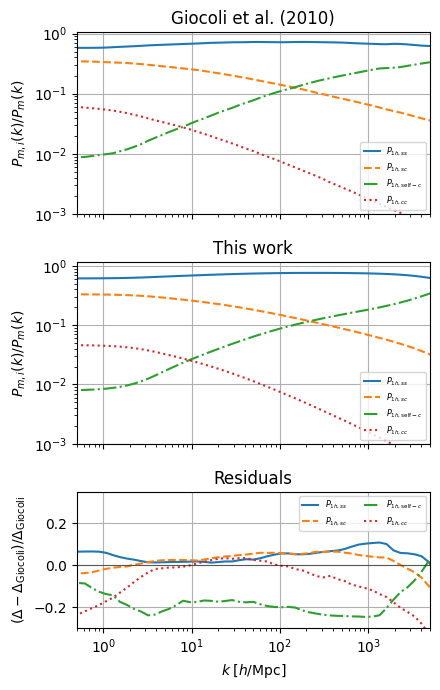

In [12]:
# plot giocoli data and my data

ss_giocoli = f_ss(np.log(k_vals))
sc_giocoli = f_sc(np.log(k_vals))
self_c_giocoli = f_self_c(np.log(k_vals))
cc_giocoli = f_cc(np.log(k_vals))

# plot the residual of my computation with giocoli data

res_ss = (ss_ratio - ss_giocoli) / ss_giocoli
res_sc = (sc_ratio - sc_giocoli) / sc_giocoli
res_self_c = (self_c_ratio - self_c_giocoli) / self_c_giocoli
res_cc = (cc_ratio - cc_giocoli) / cc_giocoli


fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(4.5, 7),
    sharex=True,
        gridspec_kw={
        'height_ratios': [2, 2, 1.5],
    }
)
fig.subplots_adjust(
    hspace=0.02,
    left=0.15,
    right=0.98,
    top=0.97,
    bottom=0.10
)

# --- Giocoli data ---
ax1.plot(k_vals, ss_giocoli, label=r'$P_{1h,ss}$', linestyle='-')
ax1.plot(k_vals, sc_giocoli, label=r'$P_{1h,sc}$', linestyle='--')
ax1.plot(k_vals, self_c_giocoli, label=r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
ax1.plot(k_vals, cc_giocoli, label=r'$P_{1h,cc}$', linestyle=':')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.5, 5e3)
ax1.set_ylim(1e-3, None)
ax1.grid()
ax1.legend(fontsize='xx-small')
ax1.set_ylabel(r'$P_{m,i}(k)/P_m(k)$')
ax1.set_title('Giocoli et al. (2010)')

# --- Your data ---
ax2.plot(k_vals, ss_ratio, label=r'$P_{1h,ss}$', linestyle='-')
ax2.plot(k_vals, sc_ratio, label=r'$P_{1h,sc}$', linestyle='--')
ax2.plot(k_vals, self_c_ratio, label=r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
ax2.plot(k_vals, cc_ratio, label=r'$P_{1h,cc}$', linestyle=':')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-3, None)
ax2.set_xlim(0.5, 5e3)
ax2.grid()
ax2.legend(fontsize='xx-small')
ax2.set_ylabel(r'$P_{m,i}(k)/P_m(k)$')
ax2.set_title('This work')

# --- Residuals ---
ax3.plot(k_vals, res_ss,     label=r'$P_{1h,ss}$', linestyle='-')
ax3.plot(k_vals, res_sc,     label=r'$P_{1h,sc}$', linestyle='--')
ax3.plot(k_vals, res_self_c, label=r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
ax3.plot(k_vals, res_cc,     label=r'$P_{1h,cc}$', linestyle=':')

ax3.axhline(0, color='k', lw=0.8, alpha=0.5)

ax3.set_xscale('log')
ax3.set_ylim(-0.3, 0.35)
ax3.set_xlim(0.5, 5e3)

ax3.grid()
ax3.legend(fontsize='xx-small', ncol=2)

ax3.set_xlabel(r'$k \; [h/\mathrm{Mpc}]$')
ax3.set_ylabel(r'$(\Delta-\Delta_\mathrm{Giocoli})/\Delta_\mathrm{Giocoli}$')
ax3.set_title('Residuals')

plt.tight_layout()
plt.savefig("Pm_1h_ratios_comparison.pdf")
plt.show()

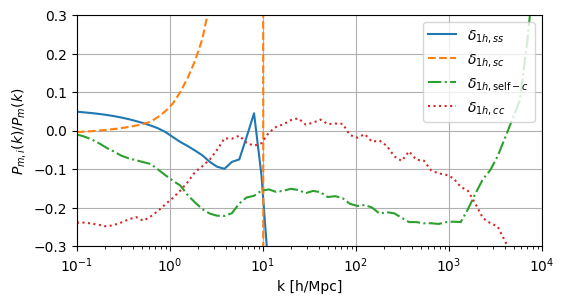

In [8]:
# plot the residual of my computation with giocoli data

res_ss = (ss_ratio - ss_giocoli) / ss_giocoli
res_sc = (sc_ratio - sc_giocoli) / sc_giocoli
res_self_c = (self_c_ratio - self_c_giocoli) / self_c_giocoli
res_cc = (cc_ratio - cc_giocoli) / cc_giocoli

# plot giocoli data

plt.figure(figsize=(6, 3))
plt.plot(k_vals, res_ss, label = r'$\delta_{1h,ss}$', linestyle='-')
plt.plot(k_vals, res_sc, label = r'$\delta_{1h,sc}$', linestyle='--')
plt.plot(k_vals, res_self_c, label = r'$\delta_{1h,\mathrm{self-}c}$', linestyle='-.')
plt.plot(k_vals, res_cc, label = r'$\delta_{1h,cc}$', linestyle=':')

plt.xscale('log')

plt.ylim(-0.3, 0.3)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("Pm_1h_ratios.pdf")
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'plots_Pm_contributions/Pm_1h_ratios.pdf'

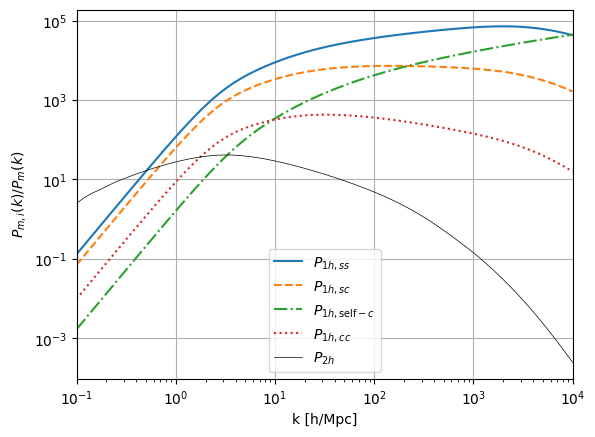

In [9]:
plt.plot(k_vals, k_vals**3 *Pm_comps['P_1h_ss'], label = r'$P_{1h,ss}$', linestyle='-')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_sc'], label = r'$P_{1h,sc}$', linestyle='--')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_self_c'], label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_cc'], label = r'$P_{1h,cc}$', linestyle=':')
plt.plot(k_vals, k_vals**3* Pm_comps['P_2h'], label=r'$P_{2h}$', color='black', linewidth = 0.5)


plt.yscale('log')
plt.xscale('log')

plt.ylim(None, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()
